In [1]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

# Research Agent 

*The goal of research is to gather the context requested by the research brief.*

Here is our overall research flow:

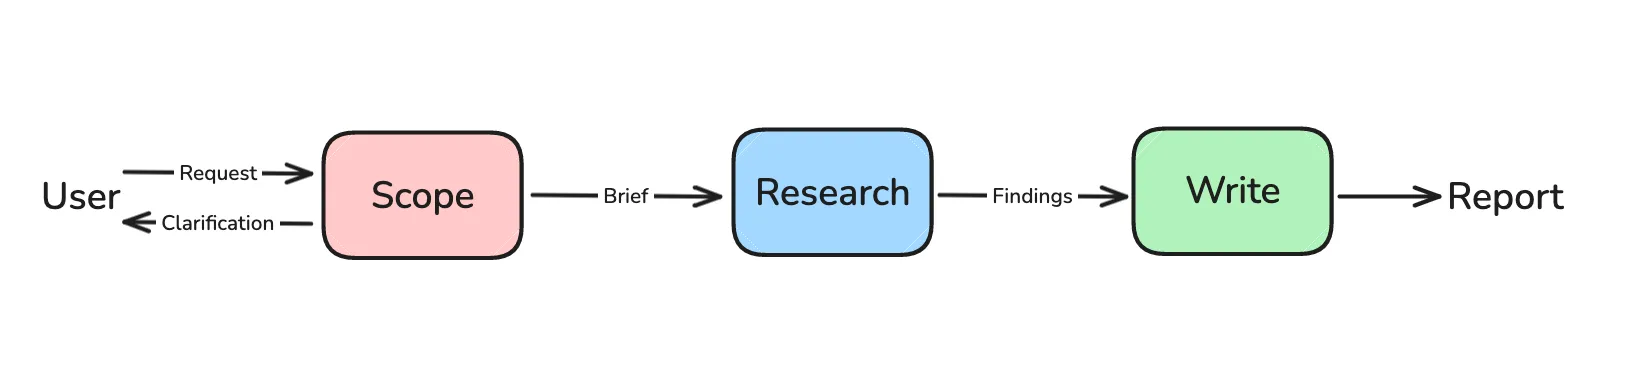

Research is an open‑ended task. The best strategy to answer a user request can't be easily known in advance. 

Requests can require different research strategies and varying levels of search depth. Consider this request:

> *"Compare these two products"*

Comparisons typically benefit from search on each product, followed by a synthesis step to compare them. Now, consider this one:

> *"Give me the top candidates for my job posting"*

Listing and ranking requests typically require open-ended search, followed by a synthesis and ranking.
 
[Agents](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent) are well suited to research because they can flexibly apply different strategies, using intermediate results to guide their exploration.

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **LLM Decision Node**: Analyzes the current state and decides whether to make tool calls or provide a final response
2. **Tool Execution Node**: Executes search tools when the LLM determines more information is needed
3. **Research Compression Node**: Summarizes and compresses research findings for efficient processing
4. **Routing Logic**: Determines workflow continuation based on LLM decisions

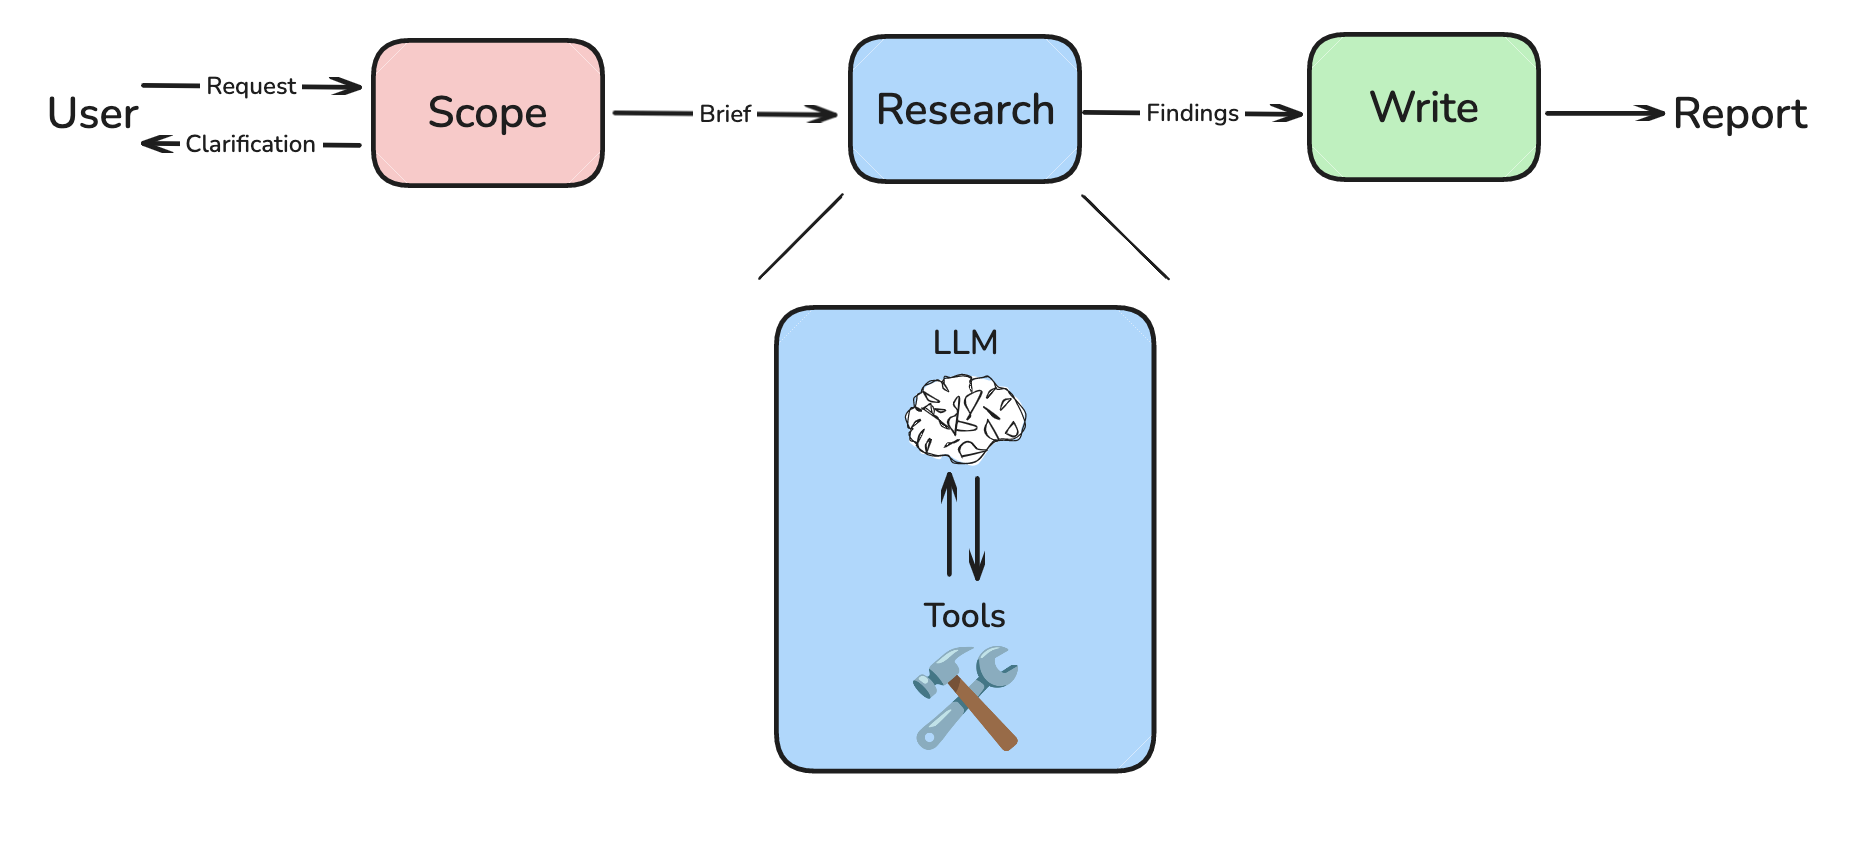

### Prompt

First, we'll define a prompt that instructs our agent to use available search tools. 

To prevent excessive tool calls and maintain research focus, we use [a few prompting techniques for agents](https://youtu.be/XSZP9GhhuAc?si=zowpViL-2j-vI9hA):

#### 1. Think Like The Agent
What instructions would you give a new work colleague?
- **Read the question carefully** - What specific information does the user need?
- **Start with broader searches** - Use broad, comprehensive queries first
- **After each search, pause and assess** - Do I have enough to answer? What's still missing?
- **Execute narrower searches as you gather information** - Fill in the gaps.

#### 2. Concrete Heuristics (Prevent "Spin-Out" on excessive tool calls)
Use **Hard Limits** to prevent the research agent from calling tools excessively:
- **Stop when you can answer confidently** - Don't keep searching for perfection.
- **Give it budgets** - Use 2-3 search tool calls for simple queries. Use up to 5 for complex queries.
- **Limit** - Always stop after 5 search tool calls if you cannot find the right source(s).

#### 3. Show your thinking
After each search tool calling, use [`think_tool` to analyze the results](https://www.anthropic.com/engineering/claude-think-tool):
- What key information did I find? 
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I search more or provide my answer?

#### Results
These techniques transform problematic research behavior like:
```
"best coffee shops SF" → "Saint Frank Coffee details" → "Sightglass Coffee details" → "Ritual Coffee details" → etc. (20+ searches)
```

Into efficient patterns like:
```
"best coffee shops SF" → ThinkTool(analyze results) → "SF specialty coffee quality ratings" → ThinkTool(assess completeness) → provide answer (3-5 searches total)
```

The key insight: **Think like a human researcher with limited time** - this prevents the "spin-out problem" where agents continue searching indefinitely.

In [2]:
from utils import show_prompt
from deep_research_from_scratch.prompts import research_agent_prompt
show_prompt(research_agent_prompt, "Research Agent Instructions")

╭────────────────────────────────────────── Research Agent Instructions ──────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the tools provided to you to find resources that can help answer the research question.     │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to two main tools:                                                                             │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Complex queries**: Use up to 5 search tool calls maximum                                                   │
│  - **Always stop**: After 5 search tool calls if you cannot find the right sources                              │
│                                                       

### State and Schemas

We'll create the agent state object.


In [3]:
%%writefile ../src/deep_research_from_scratch/state_research.py

"""
State Definitions and Pydantic Schemas for Research Agent

This module defines the state objects and structured schemas used for
the research agent workflow, including researcher state management and output schemas.
"""

import operator
from typing_extensions import TypedDict, Annotated, List, Sequence
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# ===== STATE DEFINITIONS =====

class ResearcherState(TypedDict):
    """
    State for the research agent containing message history and research metadata.
    
    This state tracks the researcher's conversation, iteration count for limiting
    tool calls, the research topic being investigated, compressed findings,
    and raw research notes for detailed analysis.
    """
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]
    tool_call_iterations: int
    research_topic: str
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]

class ResearcherOutputState(TypedDict):
    """
    Output state for the research agent containing final research results.
    
    This represents the final output of the research process with compressed
    research findings and all raw notes from the research process.
    """
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]

# ===== STRUCTURED OUTPUT SCHEMAS =====

class ClarifyWithUser(BaseModel):
    """Schema for user clarification decisions during scoping phase."""
    need_clarification: bool = Field(
        description="Whether the user needs to be asked a clarifying question.",
    )
    question: str = Field(
        description="A question to ask the user to clarify the report scope",
    )
    verification: str = Field(
        description="Verify message that we will start research after the user has provided the necessary information.",
    )

class ResearchQuestion(BaseModel):
    """Schema for research brief generation."""
    research_brief: str = Field(
        description="A research question that will be used to guide the research.",
    )

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    summary: str = Field(description="Concise summary of the webpage content")
    key_excerpts: str = Field(description="Important quotes and excerpts from the content")

Overwriting ../src/deep_research_from_scratch/state_research.py


Now, we'll define our research tool.  

#### Tavily SDK Integration

We'll use the [Tavily SDK](https://docs.tavily.com/sdk/python/reference) to perform web searches.
 
Tavily is a search engine optimized for AI applications with a generous free tier, providing:
- Real-time web search results
- Content extraction and summarization
- Domain filtering and result ranking
- Async support for performance

#### Alternative Web Content Sources

While we use Tavily's search API in this tutorial, there are several other excellent options for web content extraction:

- **[Tavily Extract](https://docs.tavily.com/documentation/api-reference/endpoint/extract)**: Tavily's dedicated content extraction endpoint that can extract and clean content from specific URLs without performing searches
- **[Jina Reader](https://jina.ai/reader/)**: A powerful web content extraction service that converts web pages to clean, LLM-friendly text by simply prepending `https://r.jina.ai/` to any URL
- **[Firecrawl](https://www.firecrawl.dev/)**: A comprehensive web scraping platform that converts websites into clean markdown or structured data, with advanced features like JavaScript rendering and sitemap crawling

Each tool has different strengths: Tavily excels at search-first workflows, Jina Reader offers the simplest URL-to-text conversion, and Firecrawl provides the most comprehensive web scraping capabilities for complex sites.

####  LangChain Tools

We'll convert our Tavily search function into a [LangChain tool](https://python.langchain.com/docs/concepts/tools/) using the `@tool` decorator. This enables:
- Automatic schema generation for the LLM
- Integration with LangChain's agent framework
- Standardized tool calling interface
- Type validation and documentation

Note that some of the arguments are noted as [InjectedToolArg](https://python.langchain.com/api_reference/core/tools/langchain_core.tools.base.InjectedToolArg.html). These are not included in the tool schema sent to the LLM, and instead are injected during execution. This gives us the flexibility to inject values at runtime, but does not burden the language model with the responsibility of managing these arguments.

In [4]:
%%writefile ../src/deep_research_from_scratch/utils.py

"""Research Utilities and Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""

from pathlib import Path
from datetime import datetime
from typing_extensions import Annotated, List, Literal

from langchain.chat_models import init_chat_model 
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool, InjectedToolArg
from tavily import TavilyClient

from deep_research_from_scratch.state_research import Summary
from deep_research_from_scratch.prompts import summarize_webpage_prompt

# ===== UTILITY FUNCTIONS =====

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def get_current_dir() -> Path:
    """Get the current directory of the module.

    This function is compatible with Jupyter notebooks and regular Python scripts.

    Returns:
        Path object representing the current directory
    """
    try:
        return Path(__file__).resolve().parent
    except NameError:  # __file__ is not defined
        return Path.cwd()

# ===== CONFIGURATION =====

summarization_model = init_chat_model(model="openai:gpt-4.1-mini")
tavily_client = TavilyClient()

# ===== SEARCH FUNCTIONS =====

def tavily_search_multiple(
    search_queries: List[str], 
    max_results: int = 3, 
    topic: Literal["general", "news", "finance"] = "general", 
    include_raw_content: bool = True, 
) -> List[dict]:
    """Perform search using Tavily API for multiple queries.

    Args:
        search_queries: List of search queries to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content

    Returns:
        List of search result dictionaries
    """
    
    # Execute searches sequentially. Note: yon can use AsyncTavilyClient to parallelize this step.
    search_docs = []
    for query in search_queries:
        result = tavily_client.search(
            query,
            max_results=max_results,
            include_raw_content=include_raw_content,
            topic=topic
        )
        search_docs.append(result)

    return search_docs

def summarize_webpage_content(webpage_content: str) -> str:
    """Summarize webpage content using the configured summarization model.
    
    Args:
        webpage_content: Raw webpage content to summarize
        
    Returns:
        Formatted summary with key excerpts
    """
    try:
        # Set up structured output model for summarization
        structured_model = summarization_model.with_structured_output(Summary)
        
        # Generate summary
        summary = structured_model.invoke([
            HumanMessage(content=summarize_webpage_prompt.format(
                webpage_content=webpage_content, 
                date=get_today_str()
            ))
        ])
        
        # Format summary with clear structure
        formatted_summary = (
            f"<summary>\n{summary.summary}\n</summary>\n\n"
            f"<key_excerpts>\n{summary.key_excerpts}\n</key_excerpts>"
        )
        
        return formatted_summary
        
    except Exception as e:
        print(f"Failed to summarize webpage: {str(e)}")
        return webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content

def deduplicate_search_results(search_results: List[dict]) -> dict:
    """Deduplicate search results by URL to avoid processing duplicate content.
    
    Args:
        search_results: List of search result dictionaries
        
    Returns:
        Dictionary mapping URLs to unique results
    """
    unique_results = {}
    
    for response in search_results:
        for result in response['results']:
            url = result['url']
            if url not in unique_results:
                unique_results[url] = result
    
    return unique_results

def process_search_results(unique_results: dict) -> dict:
    """Process search results by summarizing content where available.
    
    Args:
        unique_results: Dictionary of unique search results
        
    Returns:
        Dictionary of processed results with summaries
    """
    summarized_results = {}
    
    for url, result in unique_results.items():
        # Use existing content if no raw content for summarization
        if not result.get("raw_content"):
            content = result['content']
        else:
            # Summarize raw content for better processing
            content = summarize_webpage_content(result['raw_content'])
        
        summarized_results[url] = {
            'title': result['title'],
            'content': content
        }
    
    return summarized_results

def format_search_output(summarized_results: dict) -> str:
    """Format search results into a well-structured string output.
    
    Args:
        summarized_results: Dictionary of processed search results
        
    Returns:
        Formatted string of search results with clear source separation
    """
    if not summarized_results:
        return "No valid search results found. Please try different search queries or use a different search API."
    
    formatted_output = "Search results: \n\n"
    
    for i, (url, result) in enumerate(summarized_results.items(), 1):
        formatted_output += f"\n\n--- SOURCE {i}: {result['title']} ---\n"
        formatted_output += f"URL: {url}\n\n"
        formatted_output += f"SUMMARY:\n{result['content']}\n\n"
        formatted_output += "-" * 80 + "\n"
    
    return formatted_output

# ===== RESEARCH TOOLS =====

@tool(parse_docstring=True)
def tavily_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 3,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> str:
    """Fetch results from Tavily search API with content summarization.

    Args:
        query: A single search query to execute
        max_results: Maximum number of results to return
        topic: Topic to filter results by ('general', 'news', 'finance')

    Returns:
        Formatted string of search results with summaries
    """
    # Execute search for single query
    search_results = tavily_search_multiple(
        [query],  # Convert single query to list for the internal function
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    )

    # Deduplicate results by URL to avoid processing duplicate content
    unique_results = deduplicate_search_results(search_results)

    # Process results with summarization
    summarized_results = process_search_results(unique_results)

    # Format output for consumption
    return format_search_output(summarized_results)

@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.
    
    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.
    
    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?
    
    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?
    
    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps
        
    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"

Overwriting ../src/deep_research_from_scratch/utils.py


### Research Agent

#### Overview

Our research agent perform iterative tool-calling to search for information. 

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **LLM Decision Node**: Analyzes the current state and decides whether to make tool calls or provide a final response
2. **Tool Execution Node**: Executes search tools when the LLM determines more information is needed
3. **Research Compression Node**: Summarizes and compresses research findings for efficient processing
4. **Routing Logic**: Determines workflow continuation based on LLM decisions

#### Context Engineering Strategy

We apply **context engineering** in two places following the principles outlined in [Context Engineering for Agents](https://blog.langchain.com/context-engineering-for-agents/):

#### 1. Webpage Content Summarization
Raw search results often contain excessive noise (navigation, ads, boilerplate content). Our `summarize_webpage_content()` function:
- Uses structured output to extract key information and relevant excerpts
- Filters out irrelevant content while preserving factual details
- Compresses lengthy articles into focused summaries
- Maintains source attribution for credibility

#### 2. Research Result Compression  
As the agent performs multiple searches, the conversation context grows rapidly. Our `compress_research()` function:
- Synthesizes findings from multiple tool calls into cohesive insights
- Extracts raw notes for detailed analysis while maintaining compressed summaries
- Reduces token usage for subsequent LLM calls
- Preserves essential information for report writing

This dual-layer context engineering allows the agent to process extensive information efficiently while maintaining high-quality research output.

#### 3. Performing Careful Compression
[Compression](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus) [is risky](https://cognition.ai/blog/dont-build-multi-agents)! We need to be very careful about loosing valuable information. We'll use an LLM for compression with instructions in a system prompt that comes before a potentially long, token-heavy trajectory of multiple tool calls. The long context can cause the compression LLM [to loose sight of the task instructions](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html), leading to generic summaries that loose information. So, we reinforce the compression task by adding a `compress_research_human_message` that:
- Explicitly restates the original research topic at compression time
- Reminds the model to preserve ALL information relevant to the specific question
- Emphasizes that comprehensive findings are critical for final report generation
- Prevents task drift during the compression phase

#### 4. Output Token Management
Research compression can generate long outputs. We need to sure that they do not exceed model token limits, which can cause truncated responses that cut off mid-sentence (as seen with "**Sextant Coffee Ro" being cut off). As an example, [GPT-4.1 has output limit of up to 33k tokens](https://openai.com/index/gpt-4-1/) and [Claude4 sonnet supports 64k](https://www.anthropic.com/claude/sonnet). 

Model SDKs / LangChain integrations may cap this (e.g., [to `1024` tokens in the case of Claude](https://github.com/langchain-ai/langchain/blob/master/libs/partners/anthropic/langchain_anthropic/chat_models.py#L1149C5-L1149C15)). Simply ensure that max tokens is set to ensure complete output. This prevents incomplete compression outputs and ensures full research findings are preserved. Test compression quality vs latency for different models. For example: 

* Claude4-Sonnet 99s latency for compression ([trace](https://smith.langchain.com/public/ca006e79-8838-47eb-9d8c-c7fe7d57a6bc/r))
* GPT-4.1 38s latency for compression ([trace](https://smith.langchain.com/public/ca846b08-7501-43a0-bbda-735d4b07ab0a/r))

In [5]:
%%writefile ../src/deep_research_from_scratch/research_agent.py

"""Research Agent Implementation.

This module implements a research agent that can perform iterative web searches
and synthesis to answer complex research questions.
"""

from pydantic import BaseModel, Field
from typing_extensions import Literal

from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage, filter_messages
from langchain.chat_models import init_chat_model

from deep_research_from_scratch.state_research import ResearcherState, ResearcherOutputState
from deep_research_from_scratch.utils import tavily_search, get_today_str, think_tool
from deep_research_from_scratch.prompts import research_agent_prompt, compress_research_system_prompt, compress_research_human_message

# ===== CONFIGURATION =====

# Set up tools and model binding
tools = [tavily_search, think_tool]
tools_by_name = {tool.name: tool for tool in tools}

# Initialize models
model = init_chat_model(model="anthropic:claude-sonnet-4-6")
model_with_tools = model.bind_tools(tools)
summarization_model = init_chat_model(model="openai:gpt-4.1-mini")
compress_model = init_chat_model(model="openai:gpt-4.1", max_tokens=32000) # model="anthropic:claude-sonnet-4-6", max_tokens=64000

# ===== AGENT NODES =====

def llm_call(state: ResearcherState):
    """Analyze current state and decide on next actions.
    
    The model analyzes the current conversation state and decides whether to:
    1. Call search tools to gather more information
    2. Provide a final answer based on gathered information
    
    Returns updated state with the model's response.
    """
    return {
        "researcher_messages": [
            model_with_tools.invoke(
                [SystemMessage(content=research_agent_prompt)] + state["researcher_messages"]
            )
        ]
    }

def tool_node(state: ResearcherState):
    """Execute all tool calls from the previous LLM response.
    
    Executes all tool calls from the previous LLM responses.
    Returns updated state with tool execution results.
    """
    tool_calls = state["researcher_messages"][-1].tool_calls
 
    # Execute all tool calls
    observations = []
    for tool_call in tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observations.append(tool.invoke(tool_call["args"]))
            
    # Create tool message outputs
    tool_outputs = [
        ToolMessage(
            content=observation,
            name=tool_call["name"],
            tool_call_id=tool_call["id"]
        ) for observation, tool_call in zip(observations, tool_calls)
    ]
    
    return {"researcher_messages": tool_outputs}

def compress_research(state: ResearcherState) -> dict:
    """Compress research findings into a concise summary.
    
    Takes all the research messages and tool outputs and creates
    a compressed summary suitable for the supervisor's decision-making.
    """
    
    system_message = compress_research_system_prompt.format(date=get_today_str())
    messages = [SystemMessage(content=system_message)] + state.get("researcher_messages", []) + [HumanMessage(content=compress_research_human_message)]
    response = compress_model.invoke(messages)
    
    # Extract raw notes from tool and AI messages
    raw_notes = [
        str(m.content) for m in filter_messages(
            state["researcher_messages"], 
            include_types=["tool", "ai"]
        )
    ]
    
    return {
        "compressed_research": str(response.content),
        "raw_notes": ["\n".join(raw_notes)]
    }

# ===== ROUTING LOGIC =====

def should_continue(state: ResearcherState) -> Literal["tool_node", "compress_research"]:
    """Determine whether to continue research or provide final answer.
    
    Determines whether the agent should continue the research loop or provide
    a final answer based on whether the LLM made tool calls.
    
    Returns:
        "tool_node": Continue to tool execution
        "compress_research": Stop and compress research
    """
    messages = state["researcher_messages"]
    last_message = messages[-1]
    
    # If the LLM makes a tool call, continue to tool execution
    if last_message.tool_calls:
        return "tool_node"
    # Otherwise, we have a final answer
    return "compress_research"

# ===== GRAPH CONSTRUCTION =====

# Build the agent workflow
agent_builder = StateGraph(ResearcherState, output_schema=ResearcherOutputState)

# Add nodes to the graph
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
agent_builder.add_node("compress_research", compress_research)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_node": "tool_node", # Continue research loop
        "compress_research": "compress_research", # Provide final answer
    },
)
agent_builder.add_edge("tool_node", "llm_call") # Loop back for more research
agent_builder.add_edge("compress_research", END)

# Compile the agent
researcher_agent = agent_builder.compile()

Overwriting ../src/deep_research_from_scratch/research_agent.py


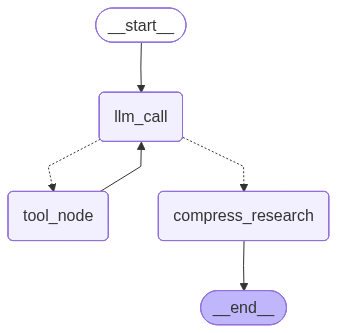

In [6]:
from IPython.display import Image, display
from deep_research_from_scratch.research_agent import researcher_agent

# Show the agent
display(Image(researcher_agent.get_graph(xray=True).draw_mermaid_png()))

In [7]:
# Run the agent
from utils import format_messages
from langchain_core.messages import HumanMessage

# Example brief
research_brief = """I want to identify and evaluate the coffee shops in San Francisco that are considered the best based specifically  
on coffee quality. My research should focus on analyzing and comparing coffee shops within the San Francisco area, 
using coffee quality as the primary criterion. I am open regarding methods of assessing coffee quality (e.g.,      
expert reviews, customer ratings, specialty coffee certifications), and there are no constraints on ambiance,      
location, wifi, or food options unless they directly impact perceived coffee quality. Please prioritize primary    
sources such as the official websites of coffee shops, reputable third-party coffee review organizations (like     
Coffee Review or Specialty Coffee Association), and prominent review aggregators like Google or Yelp where direct  
customer feedback about coffee quality can be found. The study should result in a well-supported list or ranking of
the top coffee shops in San Francisco, emphasizing their coffee quality according to the latest available data as  
of July 2025."""

result = researcher_agent.invoke({"researcher_messages": [HumanMessage(content=f"{research_brief}.")]})
format_messages(result['researcher_messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to identify and evaluate the coffee shops in San Francisco that are considered the best based            │
│ specifically                                                                                                    │
│ on coffee quality. My research should focus on analyzing and comparing coffee shops within the San Francisco    │
│ area,                                                                                                           │
│ using coffee quality as the primary criterion. I am open regarding methods of assessing coffee quality (e.g.,   │
│ expert reviews, customer ratings, specialty coffee certifications), and there are no constraints on ambiance,   │
│ location, wifi, or food options unless they directly impact perceived coffee quality. Please prioritize primary │
│ sources such as the official websites of coffee shops, reputable third-party coffee review organizations (like  │
│ Coffee Review or Specialty Coffee Association), and prominent review aggregators like Google or Yelp where      │
│ direct                                                                                                          │
│ customer feedback about coffee quality can be found. The study should result in a well-supported list or        │
│ ranking of                                                                                                      │
│ the top coffee shops in San Francisco, emphasizing their coffee quality according to the latest available data  │
│ as                                                                                                              │
│ of July 2025..                                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll research the best coffee shops in San Francisco based on coffee quality. Let me conduct multiple searches  │
│ to gather comprehensive data from various sources.                                                              │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "best coffee shops San Francisco 2025 coffee quality expert reviews"                                 │
│ }                                                                                                               │
│    ID: toolu_01DMCFLKpwLzLnri9QiCTtUL                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "San Francisco specialty coffee shops ratings 2025 Coffee Review SCA"                                │
│ }                                                                                                               │
│    ID: toolu_01EXnRaFQYUsY6NoGpdhma5D                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Best coffee in the San Francisco Bay Area ---                                                     │
│ URL: https://www.sfchronicle.com/projects/2025/best-coffee-san-francisco-bay-area                               │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ This comprehensive 2026 guide by Cesar Hernandez highlights the dynamic and evolving coffee scene across the    │
│ San Francisco Bay Area, identifying the best cafes known for innovation and quality. The article emphasizes     │
│ trends such as creamy foam drinks, experimental coffees fermented with fruits, and the rise of                  │
│ Japanese-inspired and Korean specialty coffee shops. Key venues include Ain't Normal Cafe in Oakland with       │
│ diverse roaster beans; the German-style Backhaus in San Mateo; Italian-themed The Caffè in Oakland; and         │
│ Japanese cafes like Kaizen & Coffee and Shoji in San Mateo and San Francisco respectively. Newcomers such as    │
│ Olivia Coffee and Flower in Oakland focus on Korean-roasted beans, while Masterpiece Coffee in Berkeley         │
│ specializes in Chinese coffee culture. Other notable cafes include Endless Quest Coffee Roasters in Corte       │
│ Madera, Golden Goat Coffee in San Francisco, Goodthing Coffee in Burlingame and Palo Alto, and Mind Coffee near │
│ UC Berkeley, celebrated for fruit-forward co-fermented beans. Several cafes prioritize unique beverages like    │
│ espresso tonics, coffee cream sodas, and exotic blends, reflecting the area's vibrant coffee diversity. The     │
│ guide lists 27 prominent cafes with details on offerings, atmosphere, and locations, underscoring the Bay Area  │
│ as a leading region for innovative and high-quality coffee experiences. The article also encourages readers to  │
│ contribute additional recommendations via email.                                                                │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ The Bay Area’s coffee scene is the most dynamic in the country and these shops are evidence of that., Cafes     │
│ have adopted increasingly experimental coffees, which may be fermented with fruits such as strawberry,          │
│ watermelon or passionfruit., The pinnacle of caffeinated luxury has arrived in San Francisco with Komakase, the │
│ popup behind the Bay Area’s first coffee omakase., Olivia Coffee and Flower in Oakland only brews beans roasted │
│ in Korea, bringing a slice of Korean specialty coffee to the Bay Area., Masterpiece Coffee is a singular shop   │
│ devoted to Chinese coffee culture, reflecting the country’s recent rise to prominence in coffee.                │
│ </key_excerpts>                                                                                                 │
│                                                        

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: LangSmith ---                                                                                     │
│ URL: https://smith.langchain.com/public/3090174a-8ba2-4dec-9584-b2217678cbcc/r                                  │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ The webpage documents a research effort focused on identifying and evaluating the best coffee shops in San      │
│ Francisco based specifically on coffee quality. The research primarily utilized an internal file named          │
│ 'coffee_shops_sf.md', which provided basic profiles of five notable San Francisco coffee shops: Blue Bottle     │
│ Coffee, Philz Coffee, Sightglass Coffee, Ritual Coffee Roasters, and Four Barrel Coffee, detailing their        │
│ founding dates, specialties, notable characteristics, and locations. However, the research found no additional  │
│ files or sources that included specific quality assessments, expert reviews, customer ratings, specialty        │
│ certifications, or up-to-date comparative rankings, all of which were part of the initial research criteria.    │
│ The report concludes that while these five shops represent key players in San Francisco's coffee scene, a       │
│ comprehensive ranking based solely on coffee quality would require access to further sources such as expert     │
│ review organizations (e.g., Coffee Review, Specialty Coffee Association), recent customer reviews from          │
│ platforms like Google or Yelp, and specialty certification data. These limitations restrict the ability to      │
│ produce a fully supported, quality-focused ranking as of July 2025.                                             │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ I found one relevant file ('coffee_shops_sf.md') containing basic information about 5 notable San Francisco     │
│ coffee shops, but lacking specific quality assessments or rankings., Unfortunately, the available local files   │
│ lack the specific quality-focused data you requested: expert reviews, customer ratings, specialty               │
│ certifications, and comparative rankings., To complete your research according to your specifications, you      │
│ would need access to current reviews from Coffee Review or SCA databases, recent Google/Yelp reviews focusing   │
│ on coffee quality, official websites, and specialty coffee certification data.                                  │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                        

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "Good initial results. I have some key sources:\n1. SF Chronicle's 2025/2026 guide highlighting │
│ Bay Area coffee shops\n2. Eater SF's list of 17 top coffee shops in San Francisco\n3. TripAdvisor forum with    │
│ some recommendations\n4. Yelp mentioning The Coffee Movement, Sightglass, Flywheel as top picks\n\nKey coffee   │
│ shops mentioned so far:\n- Blue Bottle Coffee\n- Ritual Coffee Roasters\n- Sightglass Coffee\n- Saint Frank     │
│ Coffee\n- Linea Caffe\n- Wrecking Ball Coffee\n- Delah Coffee House\n- Caffe Trieste\n- Philz Coffee\n- Four    │
│ Barrel Coffee\n- Golden Goat Coffee\n- Paper Son\n- The Coffee Movement\n- Flywheel Coffee\n- Cafe Shoji\n-     │
│ Hedge Coffee Roasters\n\nI need more specific quality-focused data:\n1. Expert/critic reviews focusing on       │
│ coffee quality specifically\n2. Specialty coffee certifications (SCA)\n3. Yelp/Google ratings specifically      │
│ about coffee quality\n4. Coffee Review scores if available\n5. More details on specific shops like Ritual,      │
│ Sightglass, Wrecking Ball, Saint Frank\n\nLet me search for more specific quality data on these shops and look  │
│ at Coffee Review specifically."                                                                                 │
│ }                                                                                                               │
│    ID: toolu_01MA57biM4oX7evDQ8GVRBye                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "Sightglass Coffee Saint Frank Coffee \"The Coffee Movement\" San Francisco quality specialty beans  │
│ sourcing roasting 2024 2025"                                                                                    │
│ }                                                                                                               │
│    ID: toolu_01EkTakdw3NfmxWQZyvKwefx                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Shop Sightglass Coffee | San Francisco, CA | Bean Box® ---                                        │
│ URL: https://beanbox.com/coffee/roaster/sightglass-coffee/69                                                    │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ Sightglass Coffee, founded in 2009 by siblings in San Francisco, CA, is a prominent independent coffee roaster  │
│ with two roasteries, four flagship cafés, and over 500 wholesale accounts nationwide. Committed to quality and  │
│ sustainability, Sightglass sources USDA Certified Organic coffee directly from smallholder farms worldwide,     │
│ supporting sustainable farming practices through direct trade relationships. They specialize in small-batch     │
│ roasting to maximize coffee quality, offering a range of primarily medium roast coffees with flavor notes such  │
│ as toffee, bergamot, caramel, apricot, and citrus. Products include both regular and decaf options like the     │
│ popular Owl's Howl and Hunky Dory Decaf blends. Bean Box offers eight Sightglass coffees online, available      │
│ whole bean or freshly ground, with free shipping over $75 ($45 for members) and subscription plans saving up to │
│ 20%. Customer reviews consistently praise the coffee's flavor complexity, smoothness, and brewing versatility.  │
│ Sightglass Coffee emphasizes freshness, with all coffees shipped within days of roasting.                       │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ "Sightglass Coffee began in 2009 with a leaky espresso machine behind a roll-up door in an old San Francisco    │
│ warehouse...has quietly become one of the top coffee producers in the world.", "All of their coffees are USDA   │
│ Certified Organic, sourced directly from smallholder farms...who share our devotion to freshly harvested coffee │
│ and sustainable farming.", "We roast only in small batches, ensuring that every bean is afforded the time and   │
│ care required to achieve its full expression.", "Sightglass Coffee is a direct trade roaster, sourcing through  │
│ direct trade relationships with coffee producers.", "Sightglass Coffee's coffees lean fruit-forward and sweet,  │
│ with citrusy accents. Common tasting notes include toffee, bergamot, cacao nib, apricot, and caramel."          │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                        

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "Now I have very strong data on Sightglass Coffee:\n- Founded 2009 by siblings in SF\n- Has     │
│ become \"one of the top coffee producers in the world\" (Bean Box)\n- USDA Certified Organic beans\n- Direct    │
│ trade sourcing from smallholder farms\n- Small-batch roasting\n- 2.2k Yelp reviews\n- Featured by NYT           │
│ Wirecutter, Food Network, Bon Appetit, NY Magazine\n- Multiple SF locations (SoMa, Mission, Divisadero) +       │
│ Berkeley + LA\n- 500+ wholesale accounts nationwide\n\nFor Saint Frank Coffee:\n- Mentioned in both \"Best      │
│ Coffee Roaster\" and \"Coffee Shop\" Yelp searches\n- Eater SF: known for quality Bolivian coffee\n- MistoBox:  │
│ helmed by Kevin \"Tex\" Bohlin, minimalist interior, quality espresso, strong community vibe\n\nFor Q Specialty │
│ Coffee:\n- Yelp #1 for \"Specialty Coffee\" in SF\n- Yelp top result for \"Best Coffee Roaster\" in SF\n-       │
│ Located at 3490 California St, SF\n- 277 reviews (smaller but highly rated)\n\nI now have comprehensive data    │
│ from multiple sources. I have enough to compile a thorough, well-supported analysis and ranking. Let me compile │
│ my final answer.\n\nKey shops to include in ranking:\n1. Sightglass Coffee - 2.2k Yelp reviews, USDA Organic,   │
│ direct trade, NYT Wirecutter/Bon Appetit featured, \"one of top coffee producers in world\"\n2. Ritual Coffee   │
│ Roasters - Founded 2005, pioneer of West Coast light roasting, direct trade since 2007, woman-owned, Gesha      │
│ espresso\n3. Saint Frank Coffee - Yelp top \"Coffee Shop\" and \"Best Coffee Roaster\", known for quality       │
│ sourcing, multiple locations\n4. Blue Bottle Coffee - Birthplace, third-wave pioneer, still quality-focused\n5. │
│ Wrecking Ball Coffee - Where Trish Rothgeb coined \"waves of coffee\", historically significant,                │
│ specialty-focused\n6. Linea Caffe - Espresso expertise, Eater SF recognized\n7. Q Specialty Coffee - Yelp #1    │
│ for Specialty Coffee and Best Coffee Roaster\n8. The Coffee Movement - Yelp #1 for \"best coffee\" in SF\n9.    │
│ Cafe Shoji - Award-winning MAME roasted coffee\n10. Andytown Coffee Roasters - Mentioned by Food GPS, known     │
│ quality\n11. Grand Coffee - Known for Chemex brew method\n12. Delah Coffee House - Pioneer of Yemeni coffee in  │
│ West Coast\n13. Hedge Coffee Roasters - On-site roasting in Mission District\n\nI have enough data to write a   │
│ comprehensive, well-sourced ranking. I'll stop searching and compile the answer now."                           │
│ }                                                                                                               │
│    ID: toolu_01JQvYDSZ6s1uCrwGYUFLj3s                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: Now I have very strong data on Sightglass Coffee:                                          │
│ - Founded 2009 by siblings in SF                                                                                │
│ - Has become "one of the top coffee producers in the world" (Bean Box)                                          │
│ - USDA Certified Organic beans                                                                                  │
│ - Direct trade sourcing from smallholder farms                                                                  │
│ - Small-batch roasting                                                                                          │
│ - 2.2k Yelp reviews                                                                                             │
│ - Featured by NYT Wirecutter, Food Network, Bon Appetit, NY Magazine                                            │
│ - Multiple SF locations (SoMa, Mission, Divisadero) + Berkeley + LA                                             │
│ - 500+ wholesale accounts nationwide                                                                            │
│                                                                                                                 │
│ For Saint Frank Coffee:                                                                                         │
│ - Mentioned in both "Best Coffee Roaster" and "Coffee Shop" Yelp searches                                       │
│ - Eater SF: known for quality Bolivian coffee                                                                   │
│ - MistoBox: helmed by Kevin "Tex" Bohlin, minimalist interior, quality espresso, strong community vibe          │
│                                                                                                                 │
│ For Q Specialty Coffee:                                                                                         │
│ - Yelp #1 for "Specialty Coffee" in SF                                                                          │
│ - Yelp top result for "Best Coffee Roaster" in SF                                                               │
│ - Located at 3490 California St, SF                                                                             │
│ - 277 reviews (smaller but highly rated)                                                                        │
│                                                                                                                 │
│ I now have comprehensive data from multiple sources. I have enough to compile a thorough, well-supported        │
│ analysis and ranking. Let me compile my final answer.                                                           │
│                                                                                                                 │
│ Key shops to include in ranking:                                                                                │
│ 1. Sightglass Coffee - 2.2k Yelp reviews, USDA Organic, direct trade, NYT Wirecutter/Bon Appetit featured, "one │
│ of top coffee producers in world"                                                                               │
│ 2. Ritual Coffee Roasters - Founded 2005, pioneer of West Coast light roasting, direct trade since 2007,        │
│ woman-owned, Gesha espresso                                                                                     │
│ 3. Saint Frank Coffee - Yelp top "Coffee Shop" and "Best Coffee Roaster", known for quality sourcing, multiple  │
│ locations                                                                                                       │
│ 4. Blue Bottle Coffee - Birthplace, third-wave pioneer, still quality-focused                                   │
│ 5. Wrecking Ball Coffee - Where Trish Rothgeb coined "w

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Here is a comprehensive, well-supported evaluation and ranking of San Francisco's top coffee shops, based       │
│ specifically on **coffee quality**, drawing from expert publications, review aggregators, specialty coffee      │
│ credentials, and industry recognition as of July 2025.                                                          │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ # ☕ The Best Coffee Shops in San Francisco, Ranked by Coffee Quality (2025)                                    │
│                                                                                                                 │
│ > **Methodology Note:** This ranking synthesizes data from multiple quality-focused sources:                    │
│ > - **Expert editorial reviews**: SF Chronicle, Eater SF, Food GPS, MistoBox, Coffee Bros.                      │
│ > - **Review aggregators**: Yelp (volume + category ranking), TripAdvisor                                       │
│ > - **Specialty coffee credentials**: Direct trade sourcing, USDA Organic certification, origin transparency,   │
│ roasting practices, SCA-aligned standards                                                                       │
│ > - **Industry recognition**: Good Food Awards, "waves of coffee" legacy, third-wave pioneering status          │
│ > - **Consumer coffee-quality feedback**: Verified buyer reviews on coffee flavor, complexity, and barista      │
│ expertise                                                                                                       │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## 🥇 Tier 1 — Elite Coffee Quality (SF's Very Best)                                                            │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 1. 🏆 Sightglass Coffee                                                                                     │
│ **📍 Locations:** SoMa (270 7th St), Mission, Divisadero                                                        │
│ **🌐** (https://sightglasscoffee.com)                                                                           │
│                                                                                                                 │
│ | Quality Indicator | Details |                                                                                 │
│ |---|---|                                                                                                       │
│ | **Yelp Standing** | #2 "Best Coffee" in SF (2.2K+ reviews — highest review volume of any SF specialty coffee  │
│ shop) |                                                                                                         │
│ | **Sourcing** | USDA Certified Organic; direct trade from smallholder farms worldwide |                        │
│ | **Roasting** | Small-batch, in-house roasting visible to customers at the SoMa flagship |                     │
│ | **Media Recognition** | Featured by *NYT Wirecutter*, *Foo

In [8]:
from rich.markdown import Markdown
Markdown(result['compressed_research'])

List of Queries and Tool Calls Made                                                                                

  1 "best coffee shops San Francisco 2025 coffee quality expert reviews" [Tavily Search]                           
  2 "San Francisco specialty coffee shops ratings 2025 Coffee Review SCA" [Tavily Search]                          
  3 "Ritual Coffee Roasters Sightglass Saint Frank Linea Caffe San Francisco coffee quality review 2024 2025"      
    [Tavily Search]                                                                                                
  4 "Coffee Review San Francisco coffee shops scores specialty coffee 2024 2025" [Tavily Search]                   
  5 "Wrecking Ball Coffee Roasters Linea Caffe Andytown San Francisco specialty coffee quality awards              
    certifications" [Tavily Search]                                                                                
  6 "best San Francisco coffee shops Google ratings Yelp coffee quality 2024 2025 top ranked" [Tavily Search]      
  7 "Ritual Coffee Roasters Wrecking Ball Coffee Roasters San Francisco specialty coffee awards quality barista    
    championship" [Tavily Search]                                                                                  
  8 "Linea Caffe San Francisco espresso quality review infatuation timeout 2024 2025" [Tavily Search]              
  9 "Sightglass Coffee Saint Frank Coffee 'The Coffee Movement' San Francisco quality specialty beans sourcing     
    roasting 2024 2025" [Tavily Search]                                                                            

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Fully Comprehensive Findings                                                                                       

From SF Chronicle’s 2026 Guide: This comprehensive 2026 guide by Cesar Hernandez highlights the dynamic and        
evolving coffee scene across the San Francisco Bay Area, identifying the best cafes known for innovation and       
quality. The article emphasizes trends such as creamy foam drinks, experimental coffees fermented with fruits, and 
the rise of Japanese-inspired and Korean specialty coffee shops. Key venues include Ain't Normal Cafe in Oakland   
with diverse roaster beans; the German-style Backhaus in San Mateo; Italian-themed The Caffè in Oakland; and       
Japanese cafes like Kaizen & Coffee and Shoji in San Mateo and San Francisco respectively. Newcomers such as Olivia
Coffee and Flower in Oakland focus on Korean-roasted beans, while Masterpiece Coffee in Berkeley specializes in    
Chinese coffee culture. Other notable cafes include Endless Quest Coffee Roasters in Corte Madera, Golden Goat     
Coffee in San Francisco, Goodthing Coffee in Burlingame and Palo Alto, and Mind Coffee near UC Berkeley, celebrated
for fruit-forward co-fermented beans. Several cafes prioritize unique beverages like espresso tonics, coffee cream 
sodas, and exotic blends, reflecting the area's vibrant coffee diversity. The guide lists 27 prominent cafes with  
details on offerings, atmosphere, and locations, underscoring the Bay Area as a leading region for innovative and  
high-quality coffee experiences. The article also encourages readers to contribute additional recommendations via  
email.                                                                                                             

Key excerpts:                                                                                                      

 • The Bay Area’s coffee scene is the most dynamic in the country and these shops are evidence of that.            
 • Cafes have adopted increasingly experimental coffees, which may be fermented with fruits such as strawberry,    
   watermelon or passionfruit.                                                                                     
 • The pinnacle of caffeinated luxury has arrived i

We can see the trace [here](https://smith.langchain.com/public/30eebc0c-455e-4db7-9665-d367ebd40b4e/r).

### LangGraph Studio

Just as we did before, we can also use LangGraph Studio to visualize the agent. 

This agent has been added to the `langgraph.json` file, so you can select `research_agent` in the dropdown menu:

```
"research_agent_mcp": "./src/deep_research_from_scratch/research_agent.py:agent"
```

Run the following command to start the studio

```bash
uvx --refresh --from "langgraph-cli[inmem]" --with-editable . --python 3.11 langgraph dev --allow-blocking
```

## Eval

Agents use a self-directed trajectory of tool calls to accomplish tasks.

Let's think about the ramifications of a poorly tuned tool-calling loop: 

- Early Termination: The agent decides to stop calling tools when the task is not actually complete. 
- Prolonged Looping: The agent is never satisfied with the state of its information. 

The first failure  mode results in the agent collecting insufficient information. In the deep research context, the answer may end up being too shallow. The second failure mode results in the agent utilizing an excessive number of tokens. In the deep research context, irrelevant information may poison the result.

We tuned our prompt to avoid these problems. But, let's se up a toy eval dataset that allows us to easily test agent decision-making.

In [9]:
from langchain_core.messages import AIMessage, ToolMessage, HumanMessage

# Scenario 1: Agent should CONTINUE - has insufficient/irrelevant information + think_tool realizes more research needed
messages_should_continue = [
    HumanMessage(content="What are the top coffee shops in San Francisco based on coffee quality?"),
    AIMessage(
        content="I'll search for information about top coffee shops in San Francisco focusing on coffee quality.",
        tool_calls=[
            {
                "name": "tavily_search",
                "args": {
                    "query": "coffee shops San Francisco popular locations"
                },
                "id": "call_continue_search_001",
                "type": "tool_call"
            }
        ]
    ),
    # Tavily Search provides generic cafe information - NOT focused on coffee quality
    ToolMessage(
        content="Search results show popular San Francisco cafes: Blue Bottle Coffee has great wifi and ambiance, Philz Coffee is known for custom blends and friendly service, Café Reveille has multiple locations with good pastries and laptop-friendly spaces. Ritual Coffee offers cozy seating and is popular with students.",
        tool_call_id="call_continue_search_001",
    ),
    # Agent uses think_tool to reflect and realizes the search results are insufficient
    AIMessage(
        content="Let me use the think_tool to analyze these search results and determine next steps.",
        tool_calls=[
            {
                "name": "think_tool",
                "args": {
                    "reflection": "Analysis of search results: The information I found focuses on general cafe features like wifi, ambiance, custom blends, and seating - but lacks specific coffee quality metrics. The user specifically asked for evaluation based on coffee quality, which would require expert reviews, professional ratings, specialty certifications, or quality-focused customer feedback. I need to search specifically for coffee quality assessments, Coffee Review scores, specialty coffee credentials, or expert evaluations of SF coffee shops. The current information is insufficient to answer the user's question about coffee quality."
                },
                "id": "call_continue_think_001",
                "type": "tool_call"
            }
        ]
    ),
    # think_tool response identifies the gap and need for more targeted research
    ToolMessage(
        content="Reflection recorded: Analysis of search results: The information I found focuses on general cafe features like wifi, ambiance, custom blends, and seating - but lacks specific coffee quality metrics. The user specifically asked for evaluation based on coffee quality, which would require expert reviews, professional ratings, specialty certifications, or quality-focused customer feedback. I need to search specifically for coffee quality assessments, Coffee Review scores, specialty coffee credentials, or expert evaluations of SF coffee shops. The current information is insufficient to answer the user's question about coffee quality.",
        tool_call_id="call_continue_think_001",
    )
]

# Scenario 2: Agent should STOP - has comprehensive coffee quality information + think_tool reflection
messages_should_stop = [
    HumanMessage(content="What are the top coffee shops in San Francisco based on coffee quality?"),
    AIMessage(
        content="I'll research San Francisco coffee shops specifically focusing on coffee quality assessments and expert reviews.",
        tool_calls=[
            {
                "name": "tavily_search",
                "args": {
                    "query": "best coffee quality San Francisco specialty coffee expert reviews Coffee Review ratings 2024"
                },
                "id": "call_stop_search_001", 
                "type": "tool_call"
            }
        ]
    ),
    # This ToolMessage provides COMPREHENSIVE coffee quality information - sufficient to answer the question
    ToolMessage(
        content="""Coffee quality research for San Francisco reveals top establishments based on expert reviews and specialty coffee credentials:

**Top Quality-Focused Coffee Shops:**
1. **Sightglass Coffee** - Coffee Review score 94/100, known for single-origin beans and precise roasting techniques. Featured in Bon Appétit's "Best Coffee in America" list for exceptional coffee quality.

2. **Saint Frank Coffee** - Ranked #3 coffee shop in America by The Daily Meal based on coffee quality. 4.3/5 Yelp rating with reviews specifically praising "exceptional bean quality" and "perfect extraction."

3. **Ritual Coffee Roasters** - Specialty Coffee Association member, direct trade relationships, consistently rated 4.4/5 on Google with reviews highlighting "superior coffee taste" and "expert barista skills."

4. **Blue Bottle Coffee** - Third-wave coffee pioneer, Coffee Review scores averaging 90+/100, known for rigorous quality control and fresh roasting practices.

5. **Four Barrel Coffee** - Local roaster with Coffee Review scores 88-92/100, praised by industry experts for "exceptional coffee quality" and innovative brewing methods.

**Quality Indicators Found:**
- Coffee Review professional scores (88-94/100 range)
- Specialty Coffee Association certifications
- Direct trade/single-origin sourcing
- Expert recognition from food publications
- Customer reviews specifically mentioning coffee taste and quality

This provides a comprehensive assessment of SF coffee shops based specifically on coffee quality rather than ambiance or service.""",
        tool_call_id="call_stop_search_001",
    ),
    # Agent now uses think_tool to reflect on the search results
    AIMessage(
        content="Let me reflect on the search results using the think_tool to assess whether I have sufficient information.",
        tool_calls=[
            {
                "name": "think_tool",
                "args": {
                    "reflection": "Analysis of search results: I found comprehensive coffee quality information for SF coffee shops including: 1) Professional Coffee Review scores (88-94/100), 2) Expert rankings from reputable publications, 3) Specialty Coffee Association certifications, 4) Specific quality indicators (single-origin, roasting techniques, extraction methods), 5) Five top-rated establishments with detailed quality assessments. This covers all aspects requested: expert reviews, customer ratings, specialty certifications. I have enough information to provide a well-supported ranking based specifically on coffee quality. No additional searches needed - I should provide my comprehensive answer now."
                },
                "id": "call_think_001",
                "type": "tool_call"
            }
        ]
    ),
    # think_tool response confirming reflection was recorded
    ToolMessage(
        content="Reflection recorded: Analysis of search results: I found comprehensive coffee quality information for SF coffee shops including: 1) Professional Coffee Review scores (88-94/100), 2) Expert rankings from reputable publications, 3) Specialty Coffee Association certifications, 4) Specific quality indicators (single-origin, roasting techniques, extraction methods), 5) Five top-rated establishments with detailed quality assessments. This covers all aspects requested: expert reviews, customer ratings, specialty certifications. I have enough information to provide a well-supported ranking based specifically on coffee quality. No additional searches needed - I should provide my comprehensive answer now.",
        tool_call_id="call_think_001",
    )
]

We'll create a dataset here that has one example that should continue researching, and another example that should have all of the information necessary.

In [10]:
import os
from langsmith import Client

langsmith_client = Client(api_key=os.getenv("LANGSMITH_API_KEY"))

# Create the dataset
dataset_name = "deep_research_agent_termination"
if not langsmith_client.has_dataset(dataset_name=dataset_name):

    # Create the dataset
    dataset = langsmith_client.create_dataset(
        dataset_name=dataset_name,
        description="A dataset that evaluates whether a researcher can accurately decide to continue calling tools, or to stop.",
    )
    
    # Create the examples
    langsmith_client.create_examples(
        dataset_id=dataset.id,
        examples=[
            {
                "inputs": {"researcher_messages": messages_should_continue},
                "outputs": {"next_step": "continue"},
            },
            {
                "inputs": {"researcher_messages": messages_should_stop},
                "outputs": {"next_step": "stop"},
            },
        ],
    )

Here, our evaluator is simple, using a hard-coded heuristic to check if the agent correctly continues or stops.

We'll pass in the list of messages above.

We'll assess the decision made by the agent: 

* `stop` - No tool calls means the agent should stop
* `continue` - Tool calls means the agent should continue

We'll then compare this decision to the reference expected decision `next_step`.

In [11]:
import uuid

def evaluate_next_step(outputs: dict, reference_outputs:dict):
    tool_calls = outputs["researcher_messages"][-1].tool_calls
    made_tool_call = len(tool_calls) > 0
    return {
        "key": "correct_next_step",
        "score": made_tool_call == (reference_outputs["next_step"] == "continue")
    }

def target_func(inputs: dict):
    config = {"configurable": {"thread_id": uuid.uuid4()}}
    result = researcher_agent.nodes["llm_call"].invoke(inputs, config=config)
    return result

langsmith_client.evaluate(
    target_func,
    data=dataset_name,
    evaluators=[evaluate_next_step],
    experiment_prefix="Researcher Iteration",
)

View the evaluation results for experiment: 'Researcher Iteration-420ee8bb' at:
https://smith.langchain.com/o/0b77add7-b8e6-47f1-ac77-41b7c9f1a0ec/datasets/c77b75a1-418f-4612-942b-f9942e38156b/compare?selectedSessions=a9db555c-55a1-4cbe-af81-df849e18f8b6




0it [00:00, ?it/s]

<ExperimentResults Researcher Iteration-420ee8bb>

We can see that in one example, the search tool doesn't return enough information, so we submit another search via tool call.

In the other example, we get all three top restaurants back, and so we decide to conclude.

One neat trick here - we were able to test a single node of our graph by calling `agent.nodes["node_name].invoke`